In [1]:
import sys
from pathlib import Path

# Get the absolute path of the project root (one level above notebooks/)
project_root = Path().resolve().parent

# Add "src/" to sys.path
sys.path.append(str(project_root / "src"))

In [245]:
# Download mrc file from CZII source
from cryoet_data_portal import Client, Tomogram

client = Client()

tomogram = Tomogram.get_by_id(client, 18961)
# tomogram.download_mrcfile()

100%|█████████████████████████████████████████████████████| 2.34G/2.34G [00:23<00:00, 100MiB/s]


In [2]:
# Open the MRC file

import mrcfile
import numpy as np
import os

# Load the cryo-et data
my_data_path = "../data/experimental"
# file_name = "TS_105_5.mrc"
# file_name = "TS_105_7.mrc"
file_name = "27042022_BrnoKrios_Arctis_grid9_hGIS_Position_44.mrc"
file_path = os.path.join(my_data_path, "raw", file_name)

with mrcfile.open(file_path, permissive=True) as mrc:
    cryoet_data = mrc.data  # 3D array containing intensity

    # Access header information
    print("Data shape:", mrc.data.shape)  # Dimensions of the data
    print("Voxel size (angstroms):", mrc.voxel_size)  # Voxel size if available
    print("Map origin:", mrc.header.origin)  # Origin of the map
    print("Pixel spacing:", mrc.voxel_size)  # Pixel spacing for each axis
    print("Minimum and maximum density:", mrc.header.dmin, mrc.header.dmax)
    print("Mean density:", mrc.header.dmean)

    # Other specific header fields
    print("Number of columns, rows, and sections:", mrc.header.nx, mrc.header.ny, mrc.header.nz)
    print("Data mode:", mrc.header.mode)  # Data type (e.g., byte, float)
    print("Cell dimensions (angstroms):", mrc.header.cella)  # Cell dimensions
    print("Cell angles:", mrc.header.cellb)  # Cell angles

Data shape: (512, 1024, 1024)
Voxel size (angstroms): (7.84, 7.84, 7.84)
Map origin: (0., 0., 0.)
Pixel spacing: (7.84, 7.84, 7.84)
Minimum and maximum density: -1522.4054 678.7511
Mean density: 7.860745
Number of columns, rows, and sections: 1024 1024 512
Data mode: 2
Cell dimensions (angstroms): (8028.16, 8028.16, 4014.08)
Cell angles: (90., 90., 90.)


In [82]:
# Crop and downsample data

import skimage.measure
import numpy as np
from skimage.transform import resize

# Define crop range in z, y, x
z_start, z_end = 100, 400  
y_start, y_end = 300, 600
x_start, x_end = 200, 500


# Crop the cryo-ET data
cropped = cryoet_data[z_start:z_end, y_start:y_end, x_start:x_end]

# Downsample using local mean in blocks
factor = 1
downsampled = skimage.measure.block_reduce(cropped, block_size=(factor, factor, factor), func=np.mean)

# Flip sign
downsampled = - downsampled


# Add padding to make the calculatioin space even in each direction

# Get current shape
Z, Y, X = downsampled.shape
target_size = max(Y, X)  # Make it cubic in Y/X/Z

# Calculate padding needed for Z
pad_total = target_size - Z
pad_before = pad_total // 2
pad_after = pad_total - pad_before

# Pad the Z-axis with zeros on both sides
padded = np.pad(downsampled,
                pad_width=((pad_before, pad_after), (0, 0), (0, 0)), 
                mode='constant', constant_values=0)

print("Downsampled shape:", downsampled.shape)
print("Padded shape:  ", padded.shape)

# Resize to (64, 64, 64)
resized = resize(padded, (64, 64, 64), mode='reflect', anti_aliasing=True)

print("Resized shape:  ", resized.shape)

# Global normalization over entire volume
intensity_max = 2.2
global_min = np.min(resized)
global_max = np.max(resized)
normalized = (resized - global_min) / (global_max - global_min)
normalized *= intensity_max
normalized[normalized > 1.0] = 1.0

print("Normalized shape:", normalized.shape)


Downsampled shape: (300, 300, 300)
Padded shape:   (300, 300, 300)
Resized shape:   (64, 64, 64)
Normalized shape: (64, 64, 64)


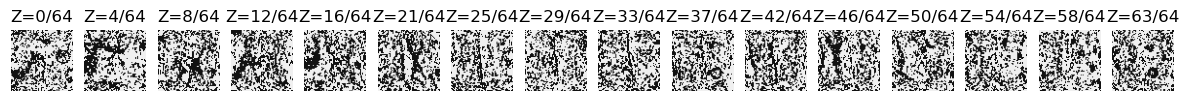

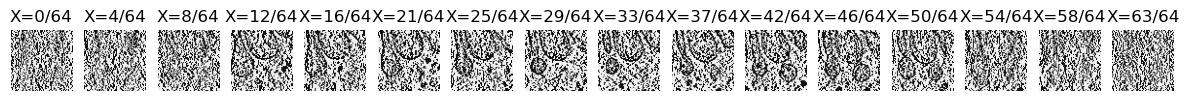

In [83]:
# Visualize data
from data_generation.mesh_to_cryoet import plot_multiple_slices

n_slices = 16
threshold = 0.8
# threshold = None

visualize = normalized
# visualize = cryoet_data

plot_multiple_slices(visualize, axis='z', num_slices=n_slices, thre=threshold)
plot_multiple_slices(visualize, axis='x', num_slices=n_slices, thre=threshold)

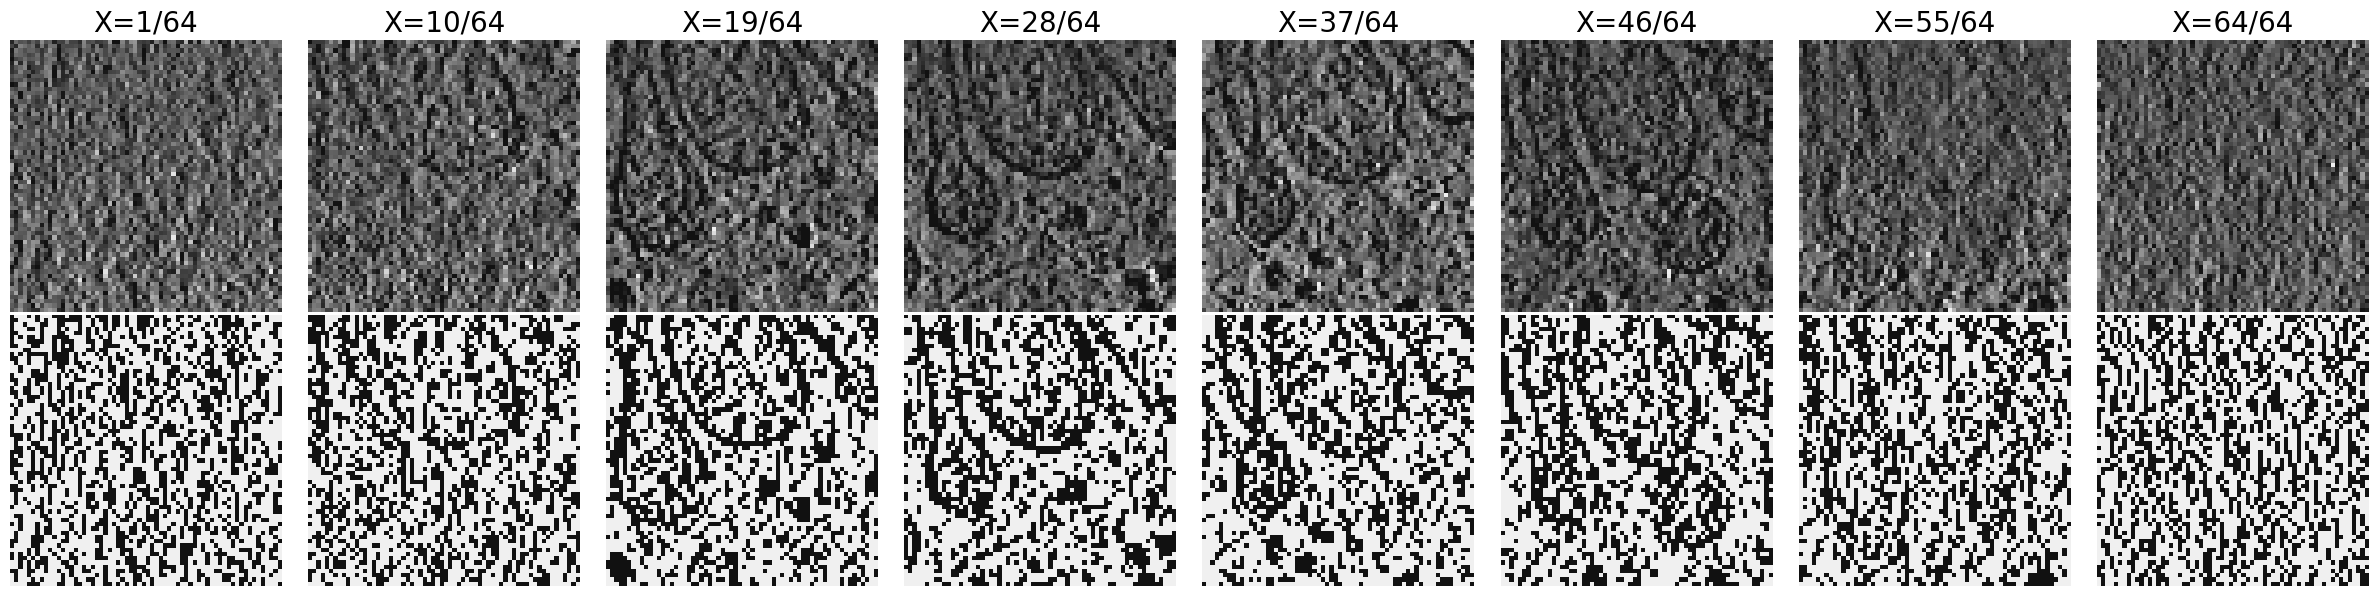

In [84]:
# Visualize slices

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Parameters
n_slices = 8
threshold = 0.8

visualize = normalized

# Evenly spaced Z indices
z_indices = np.linspace(0, visualize.shape[0] - 1, n_slices, dtype=int)

# Plot
fig, axes = plt.subplots(2, n_slices, figsize=(3 * n_slices, 6))
custom_gray = LinearSegmentedColormap.from_list('custom_gray', ['#f0f0f0', '#111111'])

for i, z_index in enumerate(z_indices):
    norm_slice = visualize[z_index, :, :]
    binary_mask = np.where(norm_slice > threshold, 1, 0)
    # binary_mask = (norm_slice > threshold).astype(np.uint8)

    # Row 1: normalized slice
    # axes[0, i].imshow(norm_slice, cmap='gray')
    axes[0, i].imshow(norm_slice, cmap=custom_gray)
    axes[0, i].set_title(f'X={z_index+1}/{visualize.shape[0]}', fontsize=20)
    axes[0, i].axis('off')

    # Row 2: thresholded mask
    axes[1, i].imshow(binary_mask, cmap=custom_gray)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


In [85]:
# Save downsampled data

data_output = normalized

output_file = os.path.join(my_data_path, "downsampled", file_name)
with mrcfile.new(output_file, overwrite=True) as mrc:
    mrc.set_data(data_output.astype(np.float32))

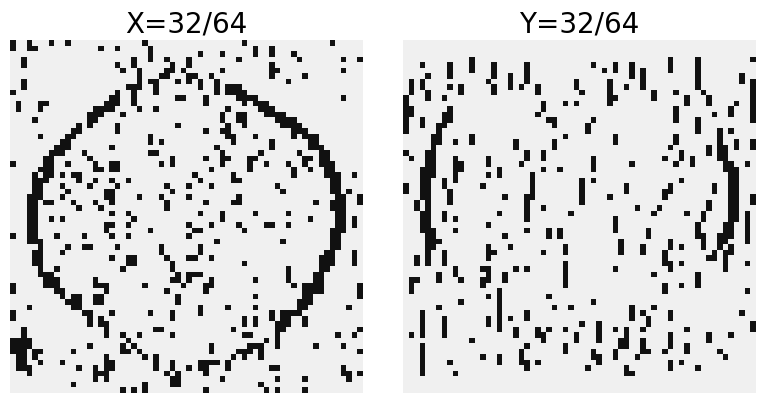

In [8]:
# Plot 2 figures

from pinn.cryoet_io import load_mrc_data
from data_generation.mesh_to_cryoet import plot_single_slice

import matplotlib.pyplot as plt

mrc_file_path = "../data/experimental/downsampled/TS_105_7.mrc"
pseudo_cryoET = load_mrc_data(mrc_file_path, grid_size=64)

thre = None
thre = 0.8

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plot_single_slice(pseudo_cryoET, ax=axes[0], axis='x', thre=thre)  # X-direction
plot_single_slice(pseudo_cryoET, ax=axes[1], axis='y', thre=thre)  # Y-direction

plt.tight_layout()
plt.show()


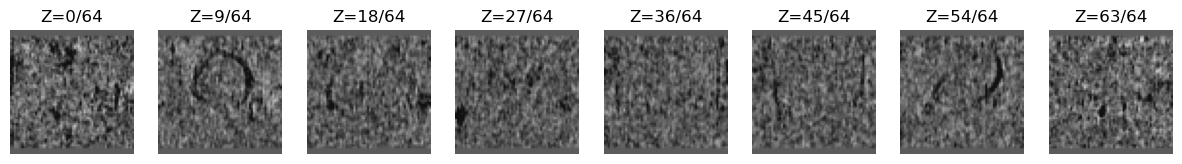

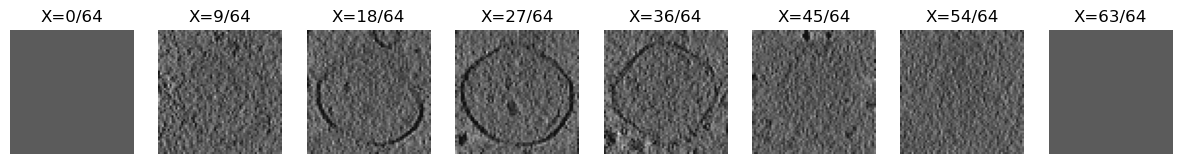

In [12]:
# Plot multiple slices

from pinn.cryoet_io import load_mrc_data
from data_generation.mesh_to_cryoet import plot_single_slice

import matplotlib.pyplot as plt

mrc_file_path = "../data/experimental/downsampled/TS_105_7.mrc"
pseudo_cryoET = load_mrc_data(mrc_file_path, grid_size=64)

thre = None
# thre = 0.8

plot_multiple_slices(pseudo_cryoET, axis='z', num_slices=8, thre=thre)
plot_multiple_slices(pseudo_cryoET, axis='x', num_slices=8, thre=thre)
